# Exercise 4.8 : Sampling from a Student's t-distribution via ULA and MALA

Sampling from a Student's $t$-distribution using two Langevin-based Markov Chain Monte Carlo (MCMC) methods:
1. Unadjusted Langevin Algorithm (ULA)
2. Metropolis-Adjusted Langevin Algorithm (MALA)

---

## 1. Mathematical Derivation

The target probability density function (pdf) is given by:
$$p_{\star}(x) = \frac{\Gamma\left(\frac{\nu+1}{2}\right)}{\sqrt{\nu\pi}\Gamma\left(\frac{\nu}{2}\right)} \left(1 + \frac{x^2}{\nu}\right)^{-\frac{\nu+1}{2}}$$

To find the score function (gradient of the log-target density), we first compute the logarithm of $p_{\star}(x)$:
$$\log p_{\star}(x) = \log\left( \frac{\Gamma\left(\frac{\nu+1}{2}\right)}{\sqrt{\nu\pi}\Gamma\left(\frac{\nu}{2}\right)} \right) - \frac{\nu+1}{2}\log\left(1 + \frac{x^2}{\nu}\right)$$

Taking the derivative with respect to $x$:
$$\nabla \log p_{\star}(x) = \frac{d}{dx}\left[ -\frac{\nu+1}{2}\log\left(1 + \frac{x^2}{\nu}\right) \right]$$
$$\nabla \log p_{\star}(x) = -\frac{\nu+1}{2} \cdot \frac{1}{1 + \frac{x^2}{\nu}} \cdot \frac{2x}{\nu}$$
$$\nabla \log p_{\star}(x) = -\frac{(\nu+1)x}{\nu \left(1 + \frac{x^2}{\nu}\right)}$$
$$\nabla \log p_{\star}(x) = -\frac{(\nu+1)x}{\nu + x^2}$$



## 2. Python Implementation

Below is the complete implementation utilizing `numpy`, `scipy`, and `matplotlib` to execute and visualize the chains.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma

def grad_log_target(x, nu):
    return (-(nu + 1) * x / (nu + x**2))

def pdf(x, nu):
    a = gamma((nu + 1) / 2)
    b = np.sqrt(nu * np.pi) * gamma(nu / 2)
    c = (1 + (x**2) / nu) ** (-(nu + 1) / 2)
    return (a / b) * c

def log_pdf(x, nu):
    return - ((nu + 1) / 2) * np.log(1 + (x**2) / nu)

# 1. Unadjusted Langevin Algorithm
def ula(nu, gam_step, n):
    samples = np.zeros(n)
    for i in range(1, n):
        current = samples[i-1]
        grad_curr = grad_log_target(current, nu)
        
        # Langevin Proposal
        new = current + gam_step * grad_curr + np.sqrt(2 * gam_step) * np.random.normal(0, 1)
        samples[i] = new
    return samples

# 2. Metropolis-Adjusted Langevin Algorithm
def mala(nu, gam_step, n):
    samples = np.zeros(n)
    for i in range(1, n):
        current = samples[i-1]
        grad_curr = grad_log_target(current, nu)
        
        new = current + gam_step * grad_curr + np.sqrt(2 * gam_step) * np.random.normal(0, 1)
        grad_new = grad_log_target(new, nu)
        
        # Transition probabilities q(x' | x) and q(x | x')
        mu_curr = new + gam_step * grad_new
        mu_new = current + gam_step * grad_curr
        
        log_q_new_given_curr = -((new - mu_new)**2) / (4 * gam_step)
        log_q_curr_given_new = -((current - mu_curr)**2) / (4 * gam_step) 
        
        # Metropolis-Hastings ratio
        log_r = (log_pdf(new, nu) + log_q_curr_given_new) - (log_pdf(current, nu) + log_q_new_given_curr)
        
        if np.log(np.random.uniform(0, 1)) < log_r:
            samples[i] = new
        else:
            samples[i] = current
    return samples

## 3. Simulation & Results Visualisation

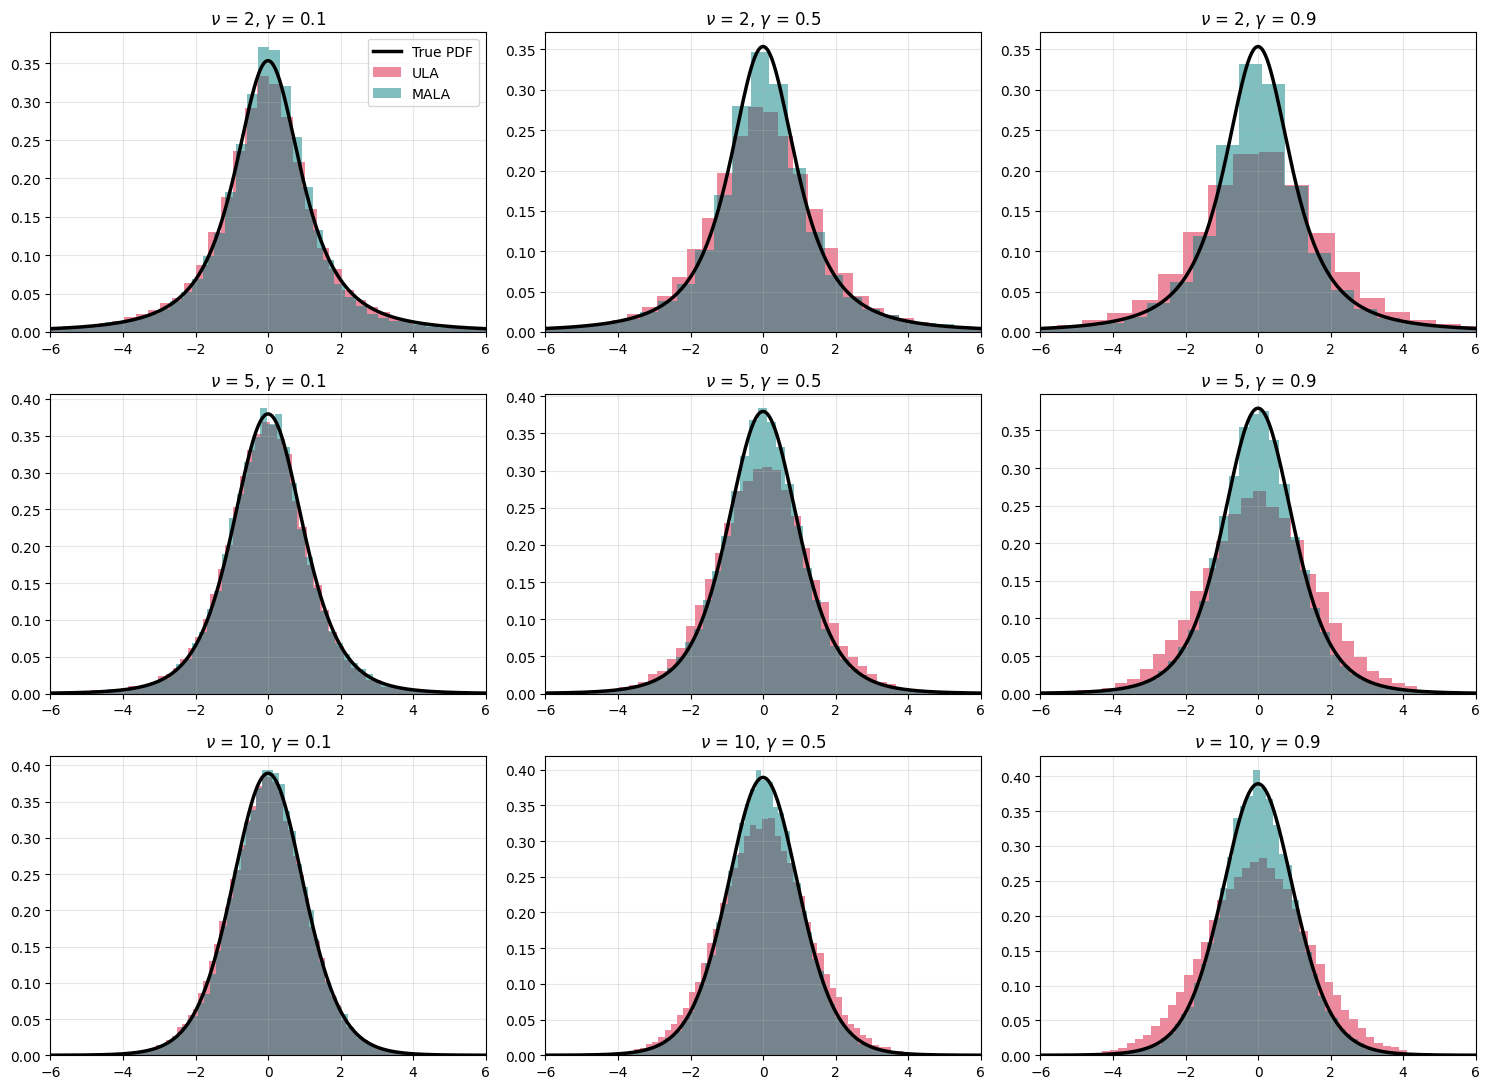

In [2]:
# --- Simulation Parameters ---
n = 50000          
burnin = 10000     
nu_values = [2, 5, 10]
gamma_values = [0.1, 0.5, 0.9]

fig, axes = plt.subplots(len(nu_values), len(gamma_values), figsize=(15, 11))

for i, nu in enumerate(nu_values):
    for j, gamma_step in enumerate(gamma_values):
        ax = axes[i, j]
        
        # Run samplers
        ula_samples = ula(nu, gamma_step, n)
        mala_samples = mala(nu, gamma_step, n)
        
        # Plot true PDF vs empirical distributions
        x_arr = np.linspace(-6, 6, 500)
        ax.plot(x_arr, pdf(x_arr, nu), 'k-', lw=2.5, label='True PDF')
        ax.hist(ula_samples[burnin:], bins=70, density=True, alpha=0.5, label='ULA', color='crimson')
        ax.hist(mala_samples[burnin:], bins=70, density=True, alpha=0.5, label='MALA', color='teal')
        
        ax.set_title(r"$\nu$ = {}, $\gamma$ = {}".format(nu, gamma_step), fontsize=12)
        ax.set_xlim(-6, 6)
        ax.grid(True, alpha=0.3)
        if i == 0 and j == 0:
            ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 4. Discussion & Key Observations


#### A. The Impact of Step-Size ($\gamma$)
-  Small Step-Sizes ($\gamma = 0.1$): Both ULA and MALA closely mimic the theoretical target density profile. Because the discretization error is small, ULA performs reasonably well even without a rejection mechanism.
- Large Step-Sizes ($\gamma = 0.9$): ULA distorts: Without a MH correction, ULA is sensible to discretization bias. When $\gamma$ is too high, ULA overshoots regions of high gradient (the slopes of the distribution), pushing samples artificially deep into the tails.
MALA remains robust and corrects for large overshoots via its acceptance test. However, choosing a $\gamma$ that is too large forces MALA to reject a large percentage of its proposals, leaving the chain stuck at the same state for prolonged intervals (sharp spikes in the histogram).

#### B. The Influence of Degrees of Freedom ($\nu$)
- Low $\nu$ ($\nu = 2$, Heavy Tails): Because the tails of Student's $t$-distribution are thick, the  gradient forces $-\frac{(\nu+1)x}{\nu + x^2}$ asymptotically approach 0 as $x \to \pm \infty$. Since the gradient vanishes at extreme distances, ULA exhibits instability in the tails because the deterministic gradient drift struggles to pull samples back toward the center against pure Brownian random noise.
- High $\nu$ ($\nu = 10$): As $\nu \to \infty$, the distribution rapidly converges towards a standard Gaussian distribution. The gradient behaves linearly ($-\frac{11x}{10+x^2} \approx -x$) near the origin, meaning both algorithms display highly efficient convergence rates and satisfactory results.
